# Project 6 — Frequency-Domain Diffusion Models for Deepfake Analysis

## 1. Imports

In [2]:
import shutil
import math
import random
from pathlib import Path
import kagglehub

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.utils import make_grid, save_image

from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/Users/ciccionos/Desktop/Secondo Primo Anno/Computer Vision/project6/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Globals

In [3]:
SEED = 42

# --- Paths -------------------------------------------------------------
KAGGLE_DATASET_NAME="greatgamedota/ffhq-face-data-set"
DATA_DIR = Path("./ffhq128")
CKPT_DIR = Path("./checkpoints")
SAMPLE_DIR = Path("./samples")
for d in (CKPT_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Device to run on --------------------------------------------------
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
DEVICE = torch.device(DEVICE)

# --- Data --------------------------------------------------------------
IMG_SIZE = 128
IMG_CHANNELS = 3
MAX_VAL_SIZE = 7000 # Max value 7000 images, aka 1/10 of the dataset
BATCH_SIZE = 32
NUM_WORKERS = 0

FREQ_MEAN = None # Assigned when run compute_freq_stats()
FREQ_STD = None

# --- DDPM --------------------------------------------------------------
TIMESTEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02

DDIM_STEPS = 50
DDIM_ETA = 0.0

# --- Training ----------------------------------------------------------
LR = 2e-4
EPOCHS = 100
LOG_EVERY = 100
SAMPLE_EVERY_EPOCHS = 5


DOMAIN = "fft" # Choose between "rgb" and "fft" to train the model on the corresponding domain


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed()
print(f"Device: {DEVICE} | domain: {DOMAIN} | image size: {IMG_SIZE}")

Device: mps | domain: fft | image size: 128


## 3. Utils

In [4]:
# ---------------------------------------------------------------------------
# 3.1 Forward and Inverse FFT
# ---------------------------------------------------------------------------

def to_freq(img: torch.Tensor) -> torch.Tensor:
    f = torch.fft.fft2(img, norm="ortho")
    f = torch.fft.fftshift(f, dim=(-2, -1))
    return torch.cat([f.real, f.imag], dim=1)


def from_freq(freq: torch.Tensor) -> torch.Tensor:
    c = freq.shape[1] // 2
    real, imag = freq[:, :c], freq[:, c:]
    f = torch.complex(real, imag)
    f = torch.fft.ifftshift(f, dim=(-2, -1))
    img = torch.fft.ifft2(f, norm="ortho").real
    return img


# ---------------------------------------------------------------------------
# 3.2 Spectral normalization
# ---------------------------------------------------------------------------

# Step 1: Logarithmic compression (log1p) and decompression (expm1)
def compress(x: torch.Tensor) -> torch.Tensor:
    return torch.sign(x) * torch.log1p(x.abs())


def decompress(x: torch.Tensor) -> torch.Tensor:
    return torch.sign(x) * torch.expm1(x.abs())


# Step 2: Channel standardization (mean/std normalization) in the frequency domain
def normalize_freq(freq: torch.Tensor) -> torch.Tensor:
    x = compress(freq)
    return (x - FREQ_MEAN.to(x.device)) / FREQ_STD.to(x.device)


def denormalize_freq(x: torch.Tensor) -> torch.Tensor:
    x = x * FREQ_STD.to(x.device) + FREQ_MEAN.to(x.device)
    return decompress(x)

# Step 3: Compute mean and std of the frequency domain
@torch.no_grad()
def compute_freq_stats(loader, n_batches: int = 30):
    sums = None
    sq_sums = None
    n_pixels = 0
    count = 0
    for batch in loader:
        img = batch.to(DEVICE)
        freq = compress(to_freq(img))
        if sums is None:
            sums = freq.sum(dim=(0, 2, 3))
            sq_sums = (freq ** 2).sum(dim=(0, 2, 3))
        else:
            sums += freq.sum(dim=(0, 2, 3))
            sq_sums += (freq ** 2).sum(dim=(0, 2, 3))
        n_pixels += img.shape[0] * img.shape[2] * img.shape[3]
        count += 1
        if count >= n_batches:
            break
    mean = sums / n_pixels
    var = sq_sums / n_pixels - mean ** 2
    std = var.clamp(min=1e-8).sqrt()
    return mean.view(-1, 1, 1).cpu(), std.view(-1, 1, 1).cpu()


# ---------------------------------------------------------------------------
# 3.3 Model space conversion
# ---------------------------------------------------------------------------

def to_model_space(img: torch.Tensor) -> torch.Tensor:
    if DOMAIN == "rgb":
        return img
    return normalize_freq(to_freq(img))


def from_model_space(x: torch.Tensor) -> torch.Tensor:
    if DOMAIN == "rgb":
        return x
    return from_freq(denormalize_freq(x))


# ---------------------------------------------------------------------------
# 3.4 Sanity check for FFT roundtrip
# ---------------------------------------------------------------------------
def fft_roundtrip_check(img_batch: torch.Tensor, tol: float = 1e-4):
    freq = to_freq(img_batch)
    recon = from_freq(freq)
    err = (img_batch - recon).abs().max().item()
    status = "OK" if err < tol else "ATTENTION: FFT roundtrip error exceeds tolerance!"
    print(f"[FFT roundtrip check] absolute maximum error: {err:.2e}  -> {status}")
    return err


# ---------------------------------------------------------------------------
# 3.5 Radial power spectrum and plotting
# ---------------------------------------------------------------------------
@torch.no_grad()
def radial_power_spectrum(img_batch: torch.Tensor, n_bins: int = 64) -> np.ndarray:
    b, c, h, w = img_batch.shape
    f = torch.fft.fft2(img_batch, norm="ortho")
    f = torch.fft.fftshift(f, dim=(-2, -1))
    power = (f.real ** 2 + f.imag ** 2).mean(dim=(0, 1))  # (H, W)

    yy, xx = torch.meshgrid(
        torch.arange(h, device=power.device) - h // 2,
        torch.arange(w, device=power.device) - w // 2,
        indexing="ij",
    )
    r = torch.sqrt(xx.float() ** 2 + yy.float() ** 2)
    r_max = r.max()
    bins = torch.linspace(0, r_max, n_bins + 1, device=power.device)

    radial_profile = np.zeros(n_bins)
    power_np = power.cpu().numpy()
    r_np = r.cpu().numpy()
    bins_np = bins.cpu().numpy()
    for i in range(n_bins):
        mask = (r_np >= bins_np[i]) & (r_np < bins_np[i + 1])
        radial_profile[i] = power_np[mask].mean() if mask.any() else 0.0
    return radial_profile


def plot_radial_spectra(spectra: dict, title: str = "Radial Power Spectra"):
    plt.figure(figsize=(6, 4))
    for label, spec in spectra.items():
        plt.plot(np.arange(len(spec)), spec + 1e-12, label=label)
    plt.yscale("log")
    plt.xlabel("Radial frequency (bin)")
    plt.ylabel("Mean power (log)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. Data

The dataset is taken from the original NVIDIA github repository [NVlabs/ffhq-dataset](https://github.com/NVlabs/ffhq-dataset) but ported in kaggle by this repo [greatgamedota/ffhq-face-data-set](https://www.kaggle.com/datasets/greatgamedota/ffhq-face-data-set)

In [ ]:
# ----------------------------------------------------------------------------
# 4.1 Download the dataset
# WARNING!!! TO RUN: only if the dataset is not downloaded yet
# ----------------------------------------------------------------------------
print(f"Downloading {KAGGLE_DATASET_NAME} dataset!")
path = kagglehub.dataset_download(KAGGLE_DATASET_NAME)
print(f"Dataset downloaded at {path}!")
shutil.move(path, DATA_DIR)

In [5]:
# ---------------------------------------------------------------------------
# 4.2 Dataset class definition and dataloaders
# ---------------------------------------------------------------------------
class FFHQDataset(Dataset):
    def __init__(self, root: Path, img_size: int = IMG_SIZE):
        self.paths = sorted(
            [p for p in Path(root).rglob("*") if p.suffix.lower() in (".png", ".jpg", ".jpeg")]
        )
        if len(self.paths) == 0:
            raise FileNotFoundError(
                f"Nessuna immagine trovata in {root} — controlla DATA_DIR nella sezione Globals."
            )
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                      # [0, 1]
            transforms.Normalize([0.5] * 3, [0.5] * 3),  # -> [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


full_dataset = FFHQDataset(DATA_DIR, IMG_SIZE)
print(f"Immagini totali trovate: {len(full_dataset)}")

val_size = min(MAX_VAL_SIZE, len(full_dataset) // 10)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {len(train_dataset)} | Val/reference (per FID e confronto spettrale): {len(val_dataset)}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

Immagini totali trovate: 70000
Train: 63000 | Val/reference (per FID e confronto spettrale): 7000


/Users/ciccionos/Desktop/Secondo Primo Anno/Computer Vision/project6/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


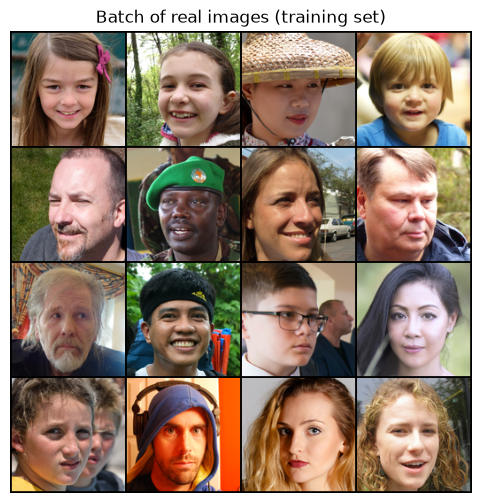

In [6]:
# ---------------------------------------------------------------------------
# 4.3 Visualization of a batch of real images
# ---------------------------------------------------------------------------
sample_batch = next(iter(train_loader))
grid = make_grid(sample_batch[:16] * 0.5 + 0.5, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Batch of real images (training set)")
plt.show()


In [7]:
# ---------------------------------------------------------------------------
# 4.4 Sanity check: FFT forward + inverse
# ---------------------------------------------------------------------------
_ = fft_roundtrip_check(sample_batch.to(DEVICE))


[FFT roundtrip check] absolute maximum error: 1.19e-06  -> OK


In [8]:
# ---------------------------------------------------------------------------
# 4.5 Frequency statistics for normalization (only if DOMAIN == 'fft')
# ---------------------------------------------------------------------------
if DOMAIN == "fft":
    FREQ_MEAN, FREQ_STD = compute_freq_stats(train_loader, n_batches=30)
    print("FREQ_MEAN shape:", FREQ_MEAN.shape, "| FREQ_STD shape:", FREQ_STD.shape)
    torch.save({"mean": FREQ_MEAN, "std": FREQ_STD}, CKPT_DIR / "freq_stats.pt")


FREQ_MEAN shape: torch.Size([6, 1, 1]) | FREQ_STD shape: torch.Size([6, 1, 1])


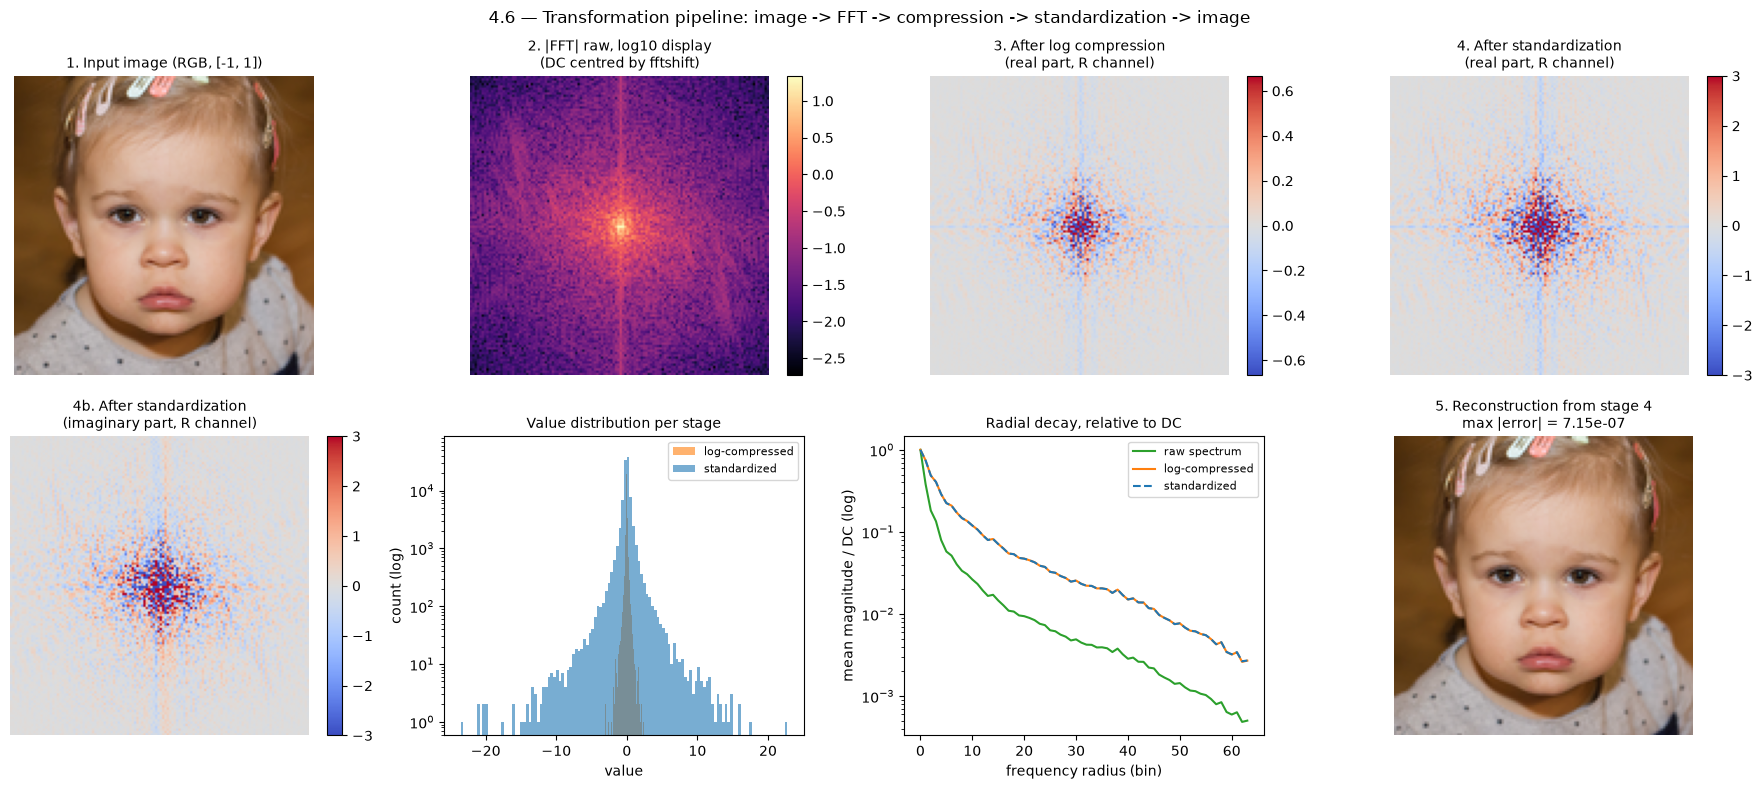

input image : min     -0.969 | max     +1.000 | mean   -0.005 | std    0.443
raw FFT     : min    -29.430 | max    +31.729 | mean   -0.003 | std    0.313
compressed  : min     -3.415 | max     +3.488 | mean   -0.001 | std    0.130
standardized: min    -23.566 | max    +22.750 | mean   -0.010 | std    0.879

Pipeline roundtrip max |error|: 7.15e-07


In [12]:
# ---------------------------------------------------------------------------
# 4.6 Transformation pipeline visualization
# ---------------------------------------------------------------------------
VIS_IDX = 22  # idx of the inmage in sample_batch

def channel_magnitude(freq: torch.Tensor) -> torch.Tensor:
    c = freq.shape[1] // 2
    return torch.sqrt(freq[0, :c] ** 2 + freq[0, c:] ** 2).mean(0)


def radial_mean(plane: torch.Tensor, n_bins: int = 64) -> np.ndarray:
    h, w = plane.shape
    yy, xx = torch.meshgrid(
        torch.arange(h, device=plane.device) - h // 2,
        torch.arange(w, device=plane.device) - w // 2,
        indexing="ij",
    )
    r = torch.sqrt(xx.float() ** 2 + yy.float() ** 2).cpu().numpy()
    values = plane.cpu().numpy()
    edges = np.linspace(0, r.max(), n_bins + 1)
    profile = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask = (r >= edges[i]) & (r < edges[i + 1])
        if mask.any():
            profile[i] = values[mask].mean()
    return profile


def show_map(ax, plane, title, cmap="magma", symmetric=False, vlim=None):
    values = plane.cpu().numpy()
    if symmetric:
        v = vlim if vlim is not None else np.percentile(np.abs(values), 99.5)
        im = ax.imshow(values, cmap="coolwarm", vmin=-v, vmax=v)
    else:
        im = ax.imshow(values, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)


with torch.no_grad():
    img = sample_batch[VIS_IDX : VIS_IDX + 1].to(DEVICE)

    raw = to_freq(img)
    comp = compress(raw)
    norm = normalize_freq(raw)
    recon = from_freq(denormalize_freq(norm))

    mag_raw, mag_comp, mag_norm = (channel_magnitude(t) for t in (raw, comp, norm))
    roundtrip_err = (img - recon).abs().max().item()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes[0, 0].imshow((img[0] * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy())
axes[0, 0].set_title("1. Input image (RGB, [-1, 1])", fontsize=10)
axes[0, 0].axis("off")
show_map(axes[0, 1], torch.log10(mag_raw + 1e-12),
         "2. |FFT| raw, log10 display\n(DC centred by fftshift)")
show_map(axes[0, 2], comp[0, 0], "3. After log compression\n(real part, R channel)",
         symmetric=True)
show_map(axes[0, 3], norm[0, 0], "4. After standardization\n(real part, R channel)",
         symmetric=True, vlim=3.0)
show_map(axes[1, 0], norm[0, 3], "4b. After standardization\n(imaginary part, R channel)",
         symmetric=True, vlim=3.0)
axes[1, 1].hist(comp.flatten().cpu().numpy(), bins=120, alpha=0.6,
                label="log-compressed", color="tab:orange")
axes[1, 1].hist(norm.flatten().cpu().numpy(), bins=120, alpha=0.6,
                label="standardized", color="tab:blue")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Value distribution per stage", fontsize=10)
axes[1, 1].set_xlabel("value")
axes[1, 1].set_ylabel("count (log)")
axes[1, 1].legend(fontsize=8)
for label, plane, color, style in (
    ("raw spectrum", mag_raw, "tab:green", "-"),
    ("log-compressed", mag_comp, "tab:orange", "-"),
    ("standardized", mag_norm, "tab:blue", "--"),
):
    profile = radial_mean(plane)
    axes[1, 2].plot(profile / profile[0], label=label, color=color, linestyle=style)
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Radial decay, relative to DC", fontsize=10)
axes[1, 2].set_xlabel("frequency radius (bin)")
axes[1, 2].set_ylabel("mean magnitude / DC (log)")
axes[1, 2].legend(fontsize=8)

axes[1, 3].imshow((recon[0] * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy())
axes[1, 3].set_title(f"5. Reconstruction from stage 4\nmax |error| = {roundtrip_err:.2e}",
                     fontsize=10)
axes[1, 3].axis("off")

plt.suptitle("4.6 — Transformation pipeline: image -> FFT -> compression -> standardization -> image")
plt.tight_layout()
plt.show()

for name, tensor in (("input image ", img), ("raw FFT     ", raw),
                     ("compressed  ", comp), ("standardized", norm)):
    print(f"{name}: min {tensor.min():+10.3f} | max {tensor.max():+10.3f} | "
          f"mean {tensor.mean():+8.3f} | std {tensor.std():8.3f}")
print(f"\nPipeline roundtrip max |error|: {roundtrip_err:.2e}")

## 5. Network

Standard UNet for DDPM, with support for frequency domain.
For our training contrains we used only 1 ResBlock for each resolution layer and SelfAttention only in the central bottleneck, to reduce the number of trainable parameters.
The upsampling process id made with ConvTranspose2d, instead of classical Nearest-Neighbor + Conv2d.

In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv(self.norm(x)).reshape(b, 3, c, h * w)
        q, k, v = qkv.unbind(1)
        attn = torch.softmax(torch.einsum("bci,bcj->bij", q, k) / math.sqrt(c), dim=-1)
        out = torch.einsum("bij,bcj->bci", attn, v).reshape(b, c, h, w)
        return x + self.proj(out)


class Down(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Up(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=None, base_ch=64,
                 ch_mults=(1, 2, 2, 4), time_dim=256):
        super().__init__()
        out_channels = out_channels or in_channels
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_ch),
            nn.Linear(base_ch, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.in_conv = nn.Conv2d(in_channels, base_ch, 3, padding=1)

        chans = [base_ch * m for m in ch_mults]
        self.down_blocks = nn.ModuleList()
        self.downs = nn.ModuleList()
        in_ch = base_ch
        for out_ch in chans:
            self.down_blocks.append(ResBlock(in_ch, out_ch, time_dim))
            self.downs.append(Down(out_ch))
            in_ch = out_ch

        self.mid_block1 = ResBlock(in_ch, in_ch, time_dim)
        self.mid_attn = SelfAttention(in_ch)
        self.mid_block2 = ResBlock(in_ch, in_ch, time_dim)

        self.up_blocks = nn.ModuleList()
        self.ups = nn.ModuleList()
        for out_ch in reversed(chans):
            self.ups.append(Up(in_ch))
            self.up_blocks.append(ResBlock(in_ch + out_ch, out_ch, time_dim))
            in_ch = out_ch

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_channels, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.in_conv(x)
        skips = []
        for block, down in zip(self.down_blocks, self.downs):
            h = block(h, t_emb)
            skips.append(h)
            h = down(h)

        h = self.mid_block1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        for up, block in zip(self.ups, self.up_blocks):
            h = up(h)
            skip = skips.pop()
            if h.shape[-2:] != skip.shape[-2:]:
                h = F.interpolate(h, size=skip.shape[-2:])
            h = torch.cat([h, skip], dim=1)
            h = block(h, t_emb)

        return self.out_conv(F.silu(self.out_norm(h)))


MODEL_CHANNELS = IMG_CHANNELS if DOMAIN == "rgb" else IMG_CHANNELS * 2
model = UNet(in_channels=MODEL_CHANNELS, out_channels=MODEL_CHANNELS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Modello '{DOMAIN}': {n_params / 1e6:.1f}M parametri, {MODEL_CHANNELS} canali in/out")

## 6. Train

Standard DDPM formulation (Ho et al., 2020): the forward process adds Gaussian noise over `T` timesteps, and the network learns to predict the noise added at each timestep (L2 loss). The only departure from a textbook DDPM is that, when `DOMAIN == \"fft\"`, noise is added to the **normalized frequency spectrum** rather than to RGB pixels — the rest of the underlying math is unchanged.

In [ ]:
# ---------------------------------------------------------------------------
# 6.1 Noise schedule
# ---------------------------------------------------------------------------
betas = torch.linspace(BETA_START, BETA_END, TIMESTEPS, device=DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


# ---------------------------------------------------------------------------
# 6.2 Noising function with reparameterization trick
# ---------------------------------------------------------------------------
def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
    s1 = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    s2 = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return s1 * x0 + s2 * noise


# ---------------------------------------------------------------------------
# 6.4 Loss function
# ---------------------------------------------------------------------------
def p_losses(model, x0_img: torch.Tensor) -> torch.Tensor:
    x0 = to_model_space(x0_img)
    b = x0.shape[0]
    t = torch.randint(0, TIMESTEPS, (b,), device=DEVICE).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    pred_noise = model(x_t, t)
    return F.mse_loss(pred_noise, noise)


In [ ]:
# ---------------------------------------------------------------------------
# 6.5 DDIM sampling function
# ---------------------------------------------------------------------------
@torch.no_grad()
def ddim_sample(model, n_samples=16, steps=DDIM_STEPS, eta=DDIM_ETA):
    model.eval()
    shape = (n_samples, MODEL_CHANNELS, IMG_SIZE, IMG_SIZE)
    x = torch.randn(shape, device=DEVICE)

    step_indices = torch.linspace(0, TIMESTEPS - 1, steps, device=DEVICE).long().flip(0)

    for i, t in enumerate(step_indices):
        t_batch = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)
        pred_noise = model(x, t_batch)

        alpha_t = alphas_cumprod[t]
        alpha_prev = alphas_cumprod[step_indices[i + 1]] if i + 1 < len(step_indices) else torch.tensor(1.0, device=DEVICE)

        x0_pred = (x - torch.sqrt(1 - alpha_t) * pred_noise) / torch.sqrt(alpha_t)
        sigma = eta * torch.sqrt((1 - alpha_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_prev)) if i + 1 < len(step_indices) else torch.tensor(0.0, device=DEVICE)
        dir_xt = torch.sqrt(1 - alpha_prev - sigma ** 2) * pred_noise
        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = torch.sqrt(alpha_prev) * x0_pred + dir_xt + sigma * noise

    return from_model_space(x).clamp(-1, 1)

In [ ]:
# ---------------------------------------------------------------------------
# 6.7 Training loop
# ---------------------------------------------------------------------------
def train(model, loader, epochs=EPOCHS, tag=DOMAIN):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    amp_device = "cuda" if DEVICE.type == "cuda" else "cpu" # MPS configuration is the same as CPU for AMP
    scaler = GradScaler(amp_device, enabled=(amp_device == "cuda"))
    step = 0
    for epoch in range(epochs):
        model.train()
        pbar = tqdm(loader, desc=f"[{tag}] epoch {epoch+1}/{epochs}")
        running_loss = 0.0
        for i, img in enumerate(pbar):
            img = img.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(amp_device, enabled=(amp_device == "cuda")):
                loss = p_losses(model, img)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            step += 1
            if step % LOG_EVERY == 0:
                pbar.set_postfix(loss=running_loss / (i + 1))

        if (epoch + 1) % SAMPLE_EVERY_EPOCHS == 0 or epoch == epochs - 1:
            torch.save(model.state_dict(), CKPT_DIR / f"unet_{tag}_epoch{epoch+1}.pt")
            imgs = ddim_sample(model, n_samples=16, steps=DDIM_STEPS)
            save_image(imgs * 0.5 + 0.5, SAMPLE_DIR / f"{tag}_epoch{epoch+1}.png", nrow=4)
            print(f"[{tag}] epoch {epoch+1}: checkpoint + campioni salvati.")

    return model


model = train(model, train_loader, epochs=EPOCHS, tag=DOMAIN)

## 7. Evaluation

WARNING!!! BEfore running, train boht (rgb and fft) models and check the checkpoint path.

In [ ]:
# ---------------------------------------------------------------------------
# 7.1 Model loading from checkpoints
# ---------------------------------------------------------------------------
model_rgb = UNet(in_channels=3, out_channels=3).to(DEVICE)
model_rgb.load_state_dict(
    torch.load(CKPT_DIR / f"unet_rgb_epoch{EPOCHS}.pt", map_location=DEVICE, weights_only=True)
)
model_rgb.eval()
print(f"Loaded RGB model from unet_rgb_epoch{EPOCHS}.pt")

model_fft = UNet(in_channels=6, out_channels=6).to(DEVICE)
model_fft.load_state_dict(
    torch.load(CKPT_DIR / f"unet_fft_epoch{EPOCHS}.pt", map_location=DEVICE, weights_only=True)
)
model_fft.eval()
print(f"Loaded FFT model from unet_fft_epoch{EPOCHS}.pt")

# ----------------------------------------------------------------------------
# Freq stats loading for FFT sampling
# ----------------------------------------------------------------------------
if FREQ_MEAN is None:
    stats = torch.load(CKPT_DIR / "freq_stats.pt", weights_only=True)
    FREQ_MEAN, FREQ_STD = stats["mean"], stats["std"]
    print("Loaded freq stats from checkpoint.")

In [ ]:
# ---------------------------------------------------------------------------
# 7.2 FID / KID / Precision-Recall
# ---------------------------------------------------------------------------
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchmetrics.image.precision_recall import PrecisionRecall


@torch.no_grad()
def compute_fid_kid(real_loader, model, domain, n_gen=5000, batch=32):
    global MODEL_CHANNELS, DOMAIN
    old_domain, old_ch = DOMAIN, MODEL_CHANNELS
    DOMAIN = domain
    MODEL_CHANNELS = 3 if domain == "rgb" else 6

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
    pr = PrecisionRecall(num_classes=10, normalize=True).to(DEVICE)
    kid = KernelInceptionDistance(subset_size=1000, normalize=True).to(DEVICE)

    for img in real_loader:
        img = (img.to(DEVICE) * 0.5 + 0.5).clamp(0, 1)
        fid.update(img, real=True)
        pr.update(img, real=True)
        kid.update(img, real=True)

    n_done = 0
    while n_done < n_gen:
        b = min(batch, n_gen - n_done)
        if b == 0:
            break
        gen = (ddim_sample(model, n_samples=b) * 0.5 + 0.5).clamp(0, 1)
        fid.update(gen, real=False)
        pr.update(gen, real=False)
        kid.update(gen, real=False)
        n_done += b

    fid_score = fid.compute().item()
    precision, recall = pr.compute()
    kid_score_mean, kid_score_std = kid.compute()

    DOMAIN, MODEL_CHANNELS = old_domain, old_ch
    print(f"[{domain}] FID: {fid_score:.2f} | KID: {kid_score_mean:.2f} ± {kid_score_std:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")
    return fid_score, kid_score_mean, kid_score_std, precision, recall


print("--- RGB baseline ---")
fid_rgb, kid_mean_rgb, kid_std_rgb, precision_rgb, recall_rgb = compute_fid_kid(val_loader, model_rgb, "rgb")

print("--- FFT model ---")
fid_fft, kid_mean_fft, kid_std_fft, precision_fft, recall_fft = compute_fid_kid(val_loader, model_fft, "fft")
torch.save({
    "fid_rgb": fid_rgb, "kid_mean_rgb": kid_mean_rgb, "kid_std_rgb": kid_std_rgb, "precision_rgb": precision_rgb, "recall_rgb": recall_rgb,
    "fid_fft": fid_fft, "kid_mean_fft": kid_mean_fft, "kid_std_fft": kid_std_fft, "precision_fft": precision_fft, "recall_fft": recall_fft
}, CKPT_DIR / "metrics_results.pt")

In [ ]:
# ---------------------------------------------------------------------------
# 7.3 Forensic Spectral Analysis 
# ---------------------------------------------------------------------------
N_SPECTRAL_SAMPLES = 256

spectral_loader = DataLoader(val_dataset, batch_size=N_SPECTRAL_SAMPLES, shuffle=True)
real_imgs = next(iter(spectral_loader)).to(DEVICE)

DOMAIN, MODEL_CHANNELS = "rgb", 3
gen_rgb = ddim_sample(model_rgb, n_samples=N_SPECTRAL_SAMPLES)

DOMAIN, MODEL_CHANNELS = "fft", 6
gen_fft = ddim_sample(model_fft, n_samples=N_SPECTRAL_SAMPLES)

spectra = {
    "Real images":           radial_power_spectrum(real_imgs),
    "DDPM RGB (baseline)":   radial_power_spectrum(gen_rgb),
    "DDPM Frequency-domain": radial_power_spectrum(gen_fft),
}
plot_radial_spectra(spectra, title="Radial Power Spectrum Comparison")

In [ ]:
# ------------------------------------------------------------------------------
# 7.4 Qualitative visual comparison 
# ------------------------------------------------------------------------------
N_VIS = 8

DOMAIN, MODEL_CHANNELS = "rgb", 3
vis_rgb = ddim_sample(model_rgb, n_samples=N_VIS)

DOMAIN, MODEL_CHANNELS = "fft", 6
vis_fft = ddim_sample(model_fft, n_samples=N_VIS)

vis_real = next(iter(DataLoader(val_dataset, batch_size=N_VIS, shuffle=True))).to(DEVICE)

real_grid = make_grid(vis_real * 0.5 + 0.5, nrow=N_VIS)
rgb_grid  = make_grid(vis_rgb  * 0.5 + 0.5, nrow=N_VIS)
freq_grid = make_grid(vis_fft  * 0.5 + 0.5, nrow=N_VIS)

fig, axes = plt.subplots(3, 1, figsize=(12, 6))
for ax, grid, title in zip(axes, [real_grid, rgb_grid, freq_grid],
                           ["Real images", "Generated — DDPM RGB", "Generated — DDPM Frequency-domain"]):
    ax.imshow(grid.permute(1, 2, 0).cpu().clamp(0, 1).numpy())
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()